# Over-representation Analysis for Olink Baseline Comparison: ARI|HC1

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(dplyr)
quiet_library(tidyr)
quiet_library(stringr)
quiet_library(ggplot2)
quiet_library(forcats)
quiet_library(ggrepel)
quiet_library(WebGestaltR)
quiet_library(viridis)

In [3]:
if(!dir.exists("/home/workspace/temp/output")) {
    dir.create("/home/workspace/temp/output")
}

outFiles <- list()

In [4]:
# function to run over-representation analysis

simplifiedORA_yearly_reference <- function(database, fdr, protein_hits){
       
    WebGestaltR::WebGestaltR(enrichMethods = 'ORA', 
                             organism ='hsapiens', 
                             isOutput = FALSE, 
                             enrichDatabaseFile = database,
                             enrichDatabaseType = 'genesymbol', 
                             interestGene = sig_proteins, 
                             interestGeneType ="genesymbol",
                             referenceSet = 'genome_protein-coding',
                             fdrThr = fdr,
                             minNum = 10,
                             maxNum = 500,
                             perNum = 10000)
                             #projectName = 'ORA_ARIvsHC1',
                             #outputDirectory = getwd())
    
    
}

## Read in Aim 1 HC1|ARI differential proteins

In [5]:
# from IDE for ALTRA Olink Results Aim 1: CON | ARI 2024-10-22

ari_dap_uuid <- '2455b335-7f8f-4839-9145-752cabfe319c' # zahin-totok-popin/2024-10-22_Risk_lm_riskVariable.csv

In [6]:
ari_dap_file <- cacheFiles(list(ari_dap_uuid))

ari_dap <- read.csv(ari_dap_file, 
                header = T, 
                stringsAsFactors = F)

nrow(ari_dap)

[1] "downloading fileID 2455b335-7f8f-4839-9145-752cabfe319c"


[1] 1327

## Pathway over-representation analysis

In [10]:
# File can be found on ALTRA-Manuscript GitHub under /Analysis/scRNA
database = '/home/workspace/temp/MSigDB/c2.cp.v7.2.symbols.gmt'

In [8]:
sig_proteins <- ari_dap %>%
    filter(qval <= 0.1) %>%
    pull(Assay)

str(sig_proteins)

 chr [1:272] "IL1B" "CCL28" "SCRN1" "HLA-DRA" "TIA1" "DPEP2" "IQGAP2" ...


In [11]:
ora <- simplifiedORA_yearly_reference(database, 0.05, sig_proteins)

Loading the functional categories...
Loading the ID list...
Loading the reference list...
Performing the enrichment analysis...


In [12]:
out_ora <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Baseline_ORA_ARIvsHC1.csv"
)

write.csv(
    ora, 
    out_ora,
    row.names = FALSE
)

outFiles <- c(outFiles, out_ora)

## Visualization: Inflammatory pathways dotplot

In [13]:
# inflammatory pathways keywords
inflam <- c('CYTOKINE', 'CHEMOKINE', 'TOLL', 'NOD', 'INFLAM', 'INTERLEUKIN', 'IL18', 'TNF', 'NEUTROPHIL', 'VASCULAR')

In [14]:
oraInflam <- ora %>%
    filter(grepl(paste0(inflam, collapse = '|'), geneSet))

nrow(oraInflam)

[1] 17

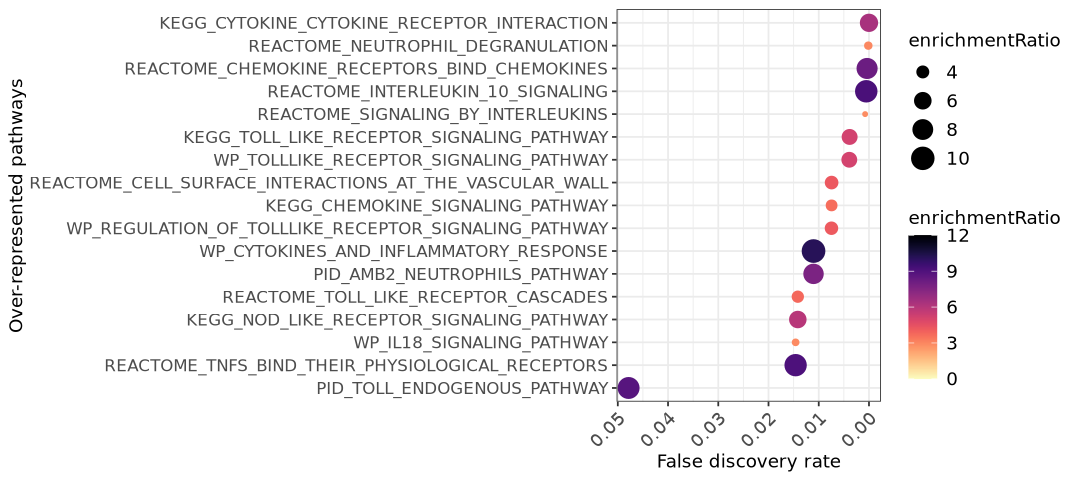

In [15]:
options(repr.plot.width = 9, repr.plot.height = 4) # default 7x7

p <- ggplot(oraInflam, aes(x=FDR, 
                           y=geneSet, 
                           size=enrichmentRatio,
                           colour=enrichmentRatio)) + 
    geom_count() + 
    aes(y=fct_reorder(geneSet, FDR, .desc = T)) +
    scale_x_reverse() +
    scale_colour_viridis(option = 'magma', 
                         discrete = FALSE, 
                         direction = -1,
                         limit = c(0,12)) +
    theme_bw() + 
    labs(x = 'False discovery rate', 
         y = 'Over-represented pathways') +
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
         #legend.position = c(0.85, 0.75),
         #legend.background = element_rect(colour = 'black', size = 0.5),
         legend.text = element_text(size=11), 
         legend.title = element_text(size=11),
         axis.text.y = element_text(size=10),
         axis.text.x = element_text(size=11, angle=45, hjust = 1, vjust =1), 
         axis.title.y = element_text(size=11), 
         axis.title.x = element_text(size=11))

print(p)

In [14]:
ggsave(filename = 'ORA_Inflammatory_Summary.pdf', 
       path = 'Figures',
       p,
       device = 'pdf', 
       width = 8, 
       height = 4, 
       units = 'in')

Manual post-processing: 
1. Removed WP_TOLLLIKE_RECEPTOR_SIGNALING due to almost identical overlap with KEGG_TOLL_LIKE_RECEPTOR_SIGNALING
2. Removed AMB2_NEUTROPHILS as leading edge proteins did not correspond to inflammation

In [15]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] viridis_0.6.5     viridisLite_0.4.2 WebGestaltR_0.4.6 ggrepel_0.9.5    
 [5] forcats_1.0.0     ggplot2_3.5.1     stringr_1.5.1     tidyr_1.3.1      
 [9] dplyr_1.1.4       hise_2.16.0      

loaded via a namespace (and not attached):
 [1] gtable_0.3.5      lattice_0.22-6    tzdb_0.4.0        vctrs_0.6.5     